# top

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F

notebook_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(notebook_dir, ".."))
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)
print(sys.path)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

%load_ext autoreload
%autoreload 2

['/mnt/ceph/users/blyo1/projects', '/mnt/sw/nix/store/71ksmx7k6xy3v9ksfkv5mp5kxxp64pd6-python-3.10.13-view/lib/python310.zip', '/mnt/sw/nix/store/71ksmx7k6xy3v9ksfkv5mp5kxxp64pd6-python-3.10.13-view/lib/python3.10', '/mnt/sw/nix/store/71ksmx7k6xy3v9ksfkv5mp5kxxp64pd6-python-3.10.13-view/lib/python3.10/lib-dynload', '', '/mnt/home/blyo1/venvs/py310/lib/python3.10/site-packages']


# load model and data

cosine_in_alpha_bar


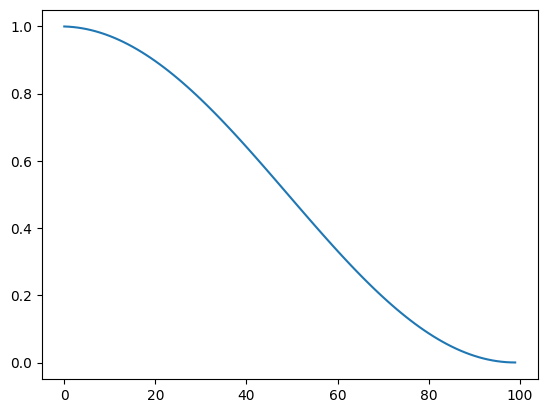

In [2]:
from b_models.configs.sami_config import SelectConfig
from utils.model_init import init_sami_model

config = SelectConfig()
config.noise_schedule = "cosine_in_alpha_bar"  # 'linear_in_beta', 'cosine_in_alpha_bar'
sami = init_sami_model(config)
print(config.noise_schedule)

fig, ax = plt.subplots(1, 1)
ax.plot(sami.alpha_bars)

[Text(0.5, 0, 'noise level'), Text(0, 0.5, 'alpha bar')]

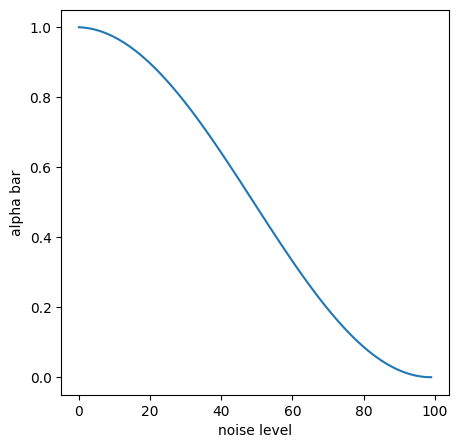

In [3]:
sigma_min, sigma_max = config.sigma_minmax

# from the SODA paper: diffusion models commonly set the variance of the additive noise term ε to follow either 
# cosine [69], sigmoid [70] or linear [5] decay schedules. 


# using the schedule outlined in the Nichol and Dhariwal (2021) paper
s = 0.01
num_timesteps = 1000
timesteps = torch.linspace(start=0, end=1, steps=num_timesteps)
f_t = torch.cos((timesteps + s) / (1 + s) * torch.pi / 2) ** 2
f_0 = np.cos(s / (1 + s) * np.pi / 2) ** 2
alpha_bars = sigma_min + (sigma_max - sigma_min) * (f_t / f_0)

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.plot(sami.alpha_bars)
ax.set(xlabel="noise level", ylabel="alpha bar")

# sqrt_one_minus_alpha_bars = torch.sqrt(1 - alpha_bars)
# self.set_schedules_from_sigma(sqrt_one_minus_alpha_bars)

[Text(0.5, 0, 'noise level'), Text(0, 0.5, 'alpha bar')]

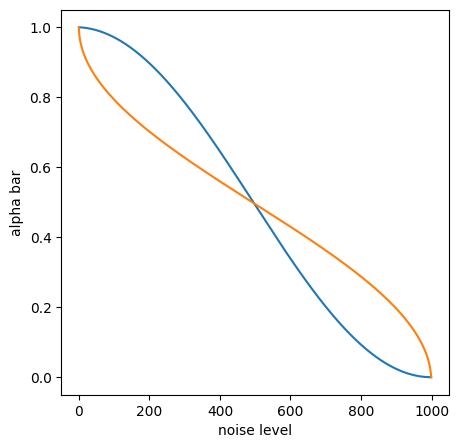

In [4]:
# invert 
def get_inverted_alpha_bars(timesteps, s=.01):
    f_0 = np.cos(s / (1 + s) * np.pi / 2) ** 2
    u = (1 + s) * (2 / np.pi) * torch.arccos(torch.sqrt(f_0 * timesteps)) - s
    u = torch.clamp(u, 0, 1)
    return u

s = 0.01
num_timesteps = 1000
timesteps = torch.linspace(start=0, end=1, steps=num_timesteps)
inverted_alpha_bars = get_inverted_alpha_bars(timesteps, s)

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.plot(alpha_bars)
ax.plot(inverted_alpha_bars)
ax.set(xlabel="noise level", ylabel="alpha bar")

[Text(0.5, 1.0, 'effect of s on inverted alpha_bar')]

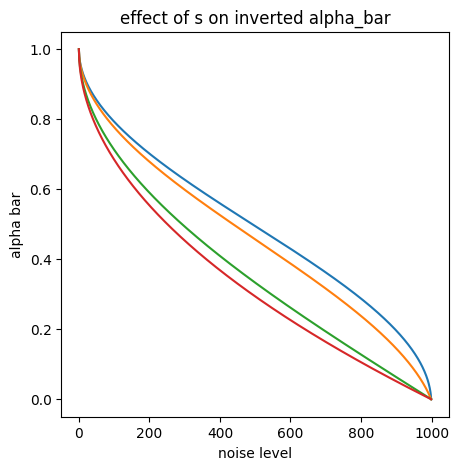

In [5]:
s_vals = [.01, .1, 1, 10]

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
for s in s_vals:
    inverted_alpha_bars = get_inverted_alpha_bars(timesteps, s)
    ax.plot(inverted_alpha_bars, label=f"{s}")
ax.set(xlabel="noise level", ylabel="alpha bar")
ax.set(title="effect of s on inverted alpha_bar")

In [6]:
def warped_inverse_alpha_bars(timesteps, s=0.008, warp_a=1):
    """inverted alpha bars, with optional warping. To emphasize the 
    middle noise levels more, decrease the value of warp_a from 1 to 0. 
    """
    from scipy.stats import beta
    u = get_inverted_alpha_bars(timesteps, s)

    from scipy.special import betainc
    u_warped = torch.from_numpy(betainc(warp_a, warp_a, u.numpy())).to(u.dtype)
    return u_warped

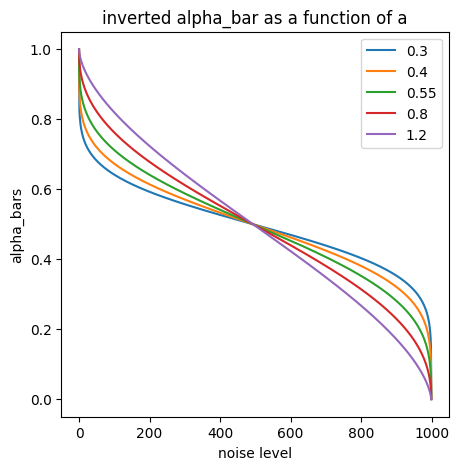

In [7]:
warp_a_vals = [.3, .4, .55, .8, 1.2]
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
for warp_a in warp_a_vals:
    a = warped_inverse_alpha_bars(timesteps, warp_a=warp_a)
    ax.plot(a, label=f"{warp_a}")
ax.legend()
ax.set(xlabel="noise level", ylabel="alpha_bars", title="inverted alpha_bar as a function of a")
plt.show()

[Text(0.5, 0, 'noise level'), Text(0, 0.5, 'alpha')]

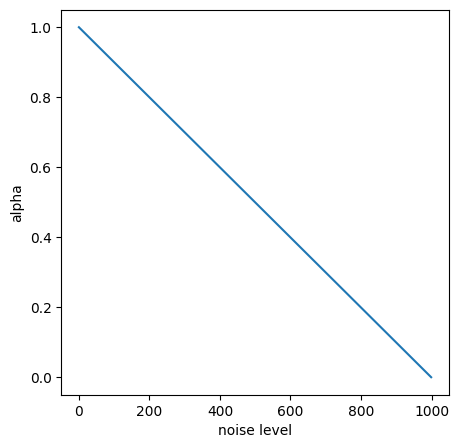

In [8]:
def get_linear_in_beta(num_timesteps):
    one_minus_alpha_bars = torch.linspace(0, 1, num_timesteps)
    return 1-one_minus_alpha_bars

alphas = get_linear_in_beta(1000)
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.plot(alphas)
ax.set(xlabel="noise level", ylabel="alpha")

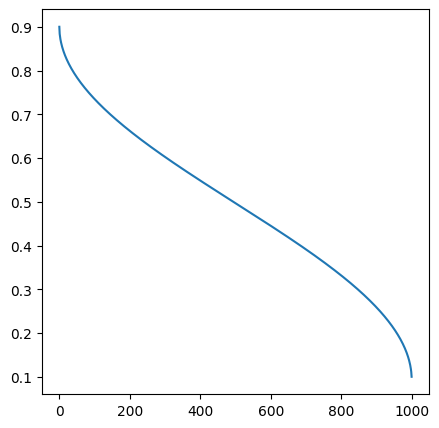

In [9]:
def get_inverted_alpha_bars(timesteps, s=0.008, warp_a=1, sigma_minmax=(0.1, 0.9)):
    """inverted alpha bars, with optional warping. To emphasize the
    middle noise levels more, decrease the value of warp_a from 1 to 0.
    """
    sigma_min, sigma_max = sigma_minmax
    f_0 = np.cos(s / (1 + s) * np.pi / 2) ** 2
    # f_t = torch.cos((timesteps + s) / (1 + s) * torch.pi / 2) ** 2
    ab = (1 + s) * (2 / np.pi) * torch.arccos(torch.sqrt(f_0 * timesteps)) - s
    ab = sigma_min + (sigma_max - sigma_min) * ab
    # u = torch.clamp(u, 0, 1)

    from scipy.special import betainc

    ab_warped = torch.from_numpy(betainc(warp_a, warp_a, ab.numpy())).to(ab.dtype)
    return ab_warped

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
u = get_inverted_alpha_bars(timesteps)
ax.plot(u)



# test built in fns

linear_in_alpha_bar


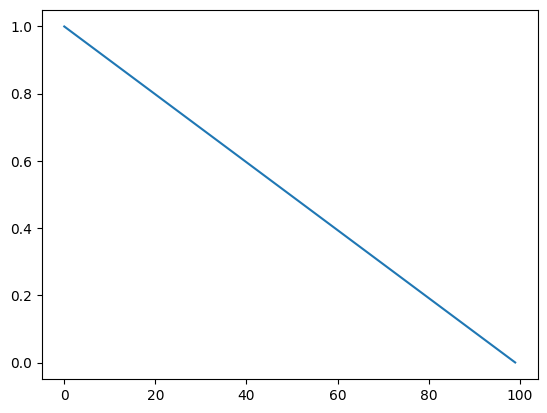

In [2]:
from b_models.configs.sami_config import SelectConfig
from utils.model_init import init_sami_model

config = SelectConfig()
config.noise_schedule = "linear_in_alpha_bar"  # 'linear_in_beta', 'cosine_in_alpha_bar'
sami = init_sami_model(config)
print(config.noise_schedule)

fig, ax = plt.subplots(1, 1)
ax.plot(sami.alpha_bars)

linear_in_beta


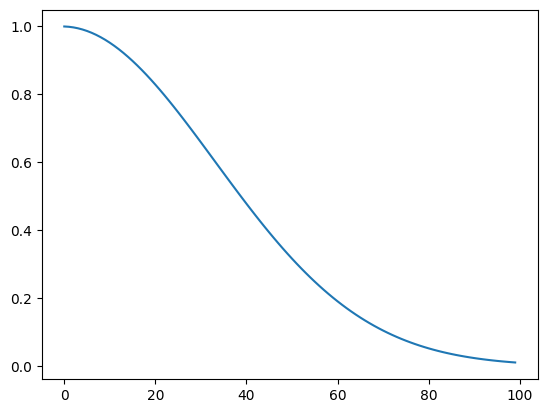

In [4]:
config = SelectConfig()
config.noise_schedule = "linear_in_beta"  # 'linear_in_beta', 'cosine_in_alpha_bar'
sami = init_sami_model(config)
print(config.noise_schedule)

fig, ax = plt.subplots(1, 1)
ax.plot(sami.alpha_bars)